In [28]:
!pip install pandas
!pip install matplotlib
!pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

location_data = pd.read_csv('./data/locations.csv')
stolen_vehicles = pd.read_csv('./data/stolen_vehicles.csv')
make_details = pd.read_csv('./data/make_details.csv')

stolen_vehicles.head()

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id
0,1,Trailer,623.0,2021.0,BST2021D,Silver,11/5/21,102
1,2,Boat Trailer,623.0,2021.0,OUTBACK BOATS FT470,Silver,12/13/21,105
2,3,Boat Trailer,623.0,2021.0,ASD JETSKI,Silver,2/13/22,102
3,4,Trailer,623.0,2021.0,MSC 7X4,Silver,11/13/21,106
4,5,Trailer,623.0,2018.0,D-MAX 8X5,Silver,1/10/22,102


In [3]:
merge_data = pd.merge(stolen_vehicles,location_data, on="location_id")
merge_data.head()

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id,region,country,population,density
0,1,Trailer,623.0,2021.0,BST2021D,Silver,11/5/21,102,Auckland,New Zealand,"1,695,200",343.09
1,2,Boat Trailer,623.0,2021.0,OUTBACK BOATS FT470,Silver,12/13/21,105,Gisborne,New Zealand,"52,100",6.21
2,3,Boat Trailer,623.0,2021.0,ASD JETSKI,Silver,2/13/22,102,Auckland,New Zealand,"1,695,200",343.09
3,4,Trailer,623.0,2021.0,MSC 7X4,Silver,11/13/21,106,Hawke's Bay,New Zealand,"182,700",12.92
4,5,Trailer,623.0,2018.0,D-MAX 8X5,Silver,1/10/22,102,Auckland,New Zealand,"1,695,200",343.09


In [4]:
region_group = merge_data.groupby('region').count()
region_group.head()

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id,country,population,density
region,,,,,,,,,,,
Auckland,1638,1626,1630,1630,1624,1630,1638,1638,1638,1638,1638
Bay of Plenty,446,442,445,445,445,445,446,446,446,446,446
Canterbury,660,660,660,660,657,660,660,660,660,660,660
Gisborne,176,175,175,175,173,175,176,176,176,176,176
Hawke's Bay,100,100,100,100,100,100,100,100,100,100,100


In [5]:
total_merge_data = pd.merge(merge_data,make_details, on="make_id")
total_merge_data.head()

,vehicle_id,vehicle_type,make_id,model_year,vehicle_desc,color,date_stolen,location_id,region,country,population,density,make_name,make_type
0,1,Trailer,623.0,2021.0,BST2021D,Silver,11/5/21,102,Auckland,New Zealand,"1,695,200",343.09,Trailer,Standard
1,2,Boat Trailer,623.0,2021.0,OUTBACK BOATS FT470,Silver,12/13/21,105,Gisborne,New Zealand,"52,100",6.21,Trailer,Standard
2,3,Boat Trailer,623.0,2021.0,ASD JETSKI,Silver,2/13/22,102,Auckland,New Zealand,"1,695,200",343.09,Trailer,Standard
3,4,Trailer,623.0,2021.0,MSC 7X4,Silver,11/13/21,106,Hawke's Bay,New Zealand,"182,700",12.92,Trailer,Standard
4,5,Trailer,623.0,2018.0,D-MAX 8X5,Silver,1/10/22,102,Auckland,New Zealand,"1,695,200",343.09,Trailer,Standard


In [34]:
total_merge_data.isnull().sum()

vehicle_id       0
vehicle_type    11
make_id          0
model_year       0
vehicle_desc    18
color            0
date_stolen      0
location_id      0
region           0
country          0
population       0
density          0
make_name        0
make_type        0
dtype: int64

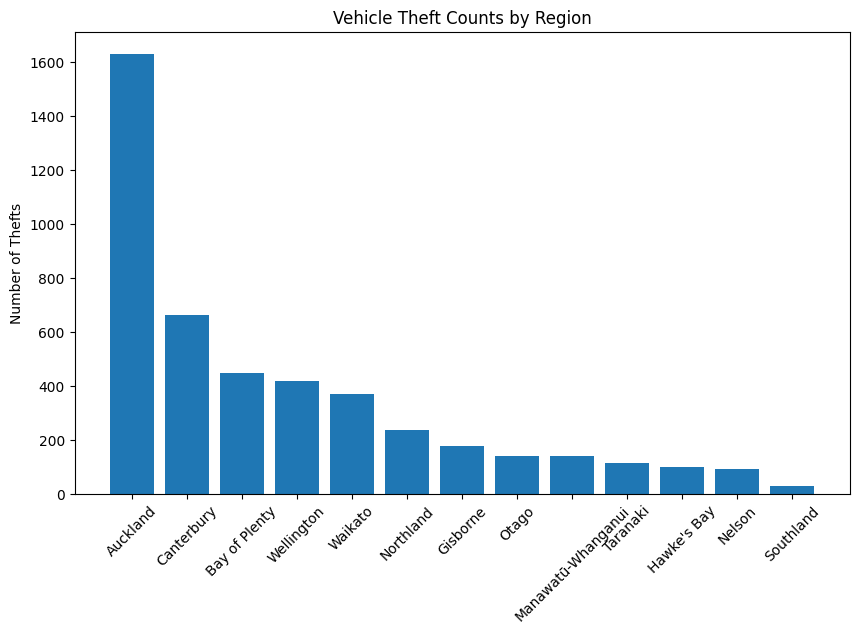

In [14]:
# Theft counts per region
region_counts = total_merge_data.groupby(["region", "country"])["vehicle_id"].count().reset_index()
region_counts = region_counts.sort_values(by="vehicle_id", ascending=False)


plt.figure(figsize=(10,6))
plt.bar(region_counts["region"], region_counts["vehicle_id"])
plt.xticks(rotation=45)
plt.title("Vehicle Theft Counts by Region")
plt.ylabel("Number of Thefts")
plt.show()

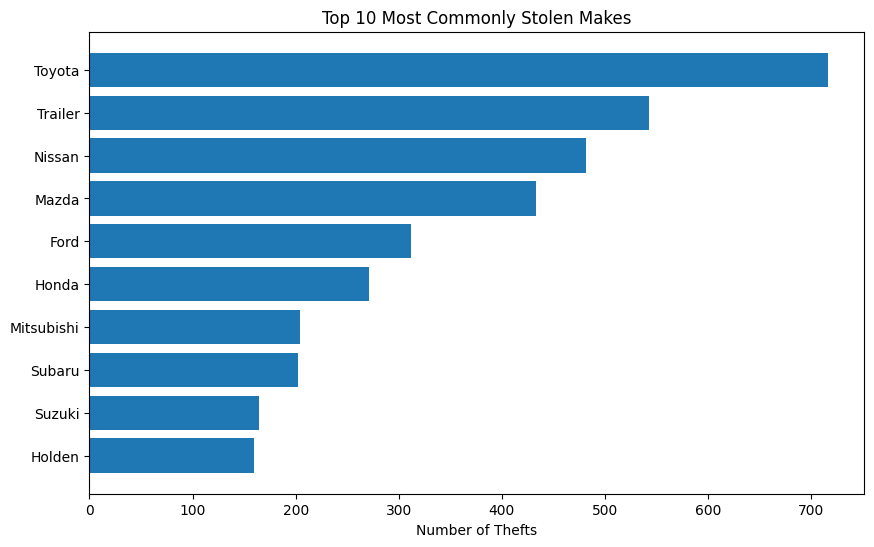

In [15]:

make_counts = total_merge_data.groupby(["make_name", "make_type"])["vehicle_id"].count().reset_index()
make_counts = make_counts.sort_values(by="vehicle_id", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(make_counts["make_name"].head(10), make_counts["vehicle_id"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Most Commonly Stolen Makes")
plt.xlabel("Number of Thefts")
plt.show()


C:\Users\sudee\AppData\Local\Temp\ipykernel_1548\900321786.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stolen_vehicles["date_stolen"] = pd.to_datetime(stolen_vehicles["date_stolen"])


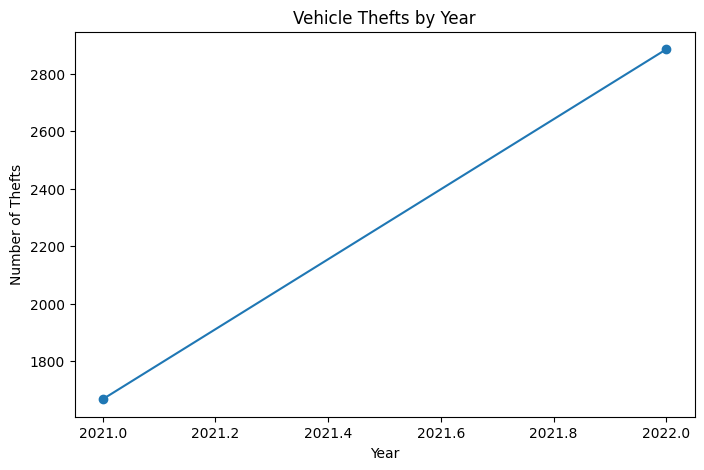

In [16]:
# Convert date_stolen to datetime
stolen_vehicles["date_stolen"] = pd.to_datetime(stolen_vehicles["date_stolen"])

# Extract year and month
stolen_vehicles["year"] = stolen_vehicles["date_stolen"].dt.year
stolen_vehicles["month"] = stolen_vehicles["date_stolen"].dt.month

# Theft counts per year
yearly_counts = stolen_vehicles.groupby("year")["vehicle_id"].count()

plt.figure(figsize=(8,5))
yearly_counts.plot(kind="line", marker="o")
plt.title("Vehicle Thefts by Year")
plt.ylabel("Number of Thefts")
plt.xlabel("Year")
plt.show()

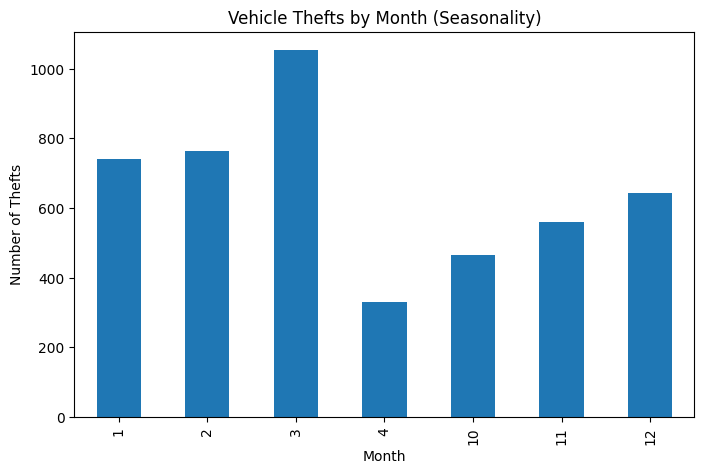

In [23]:
monthly_counts = stolen_vehicles.groupby("month")["vehicle_id"].count()
plt.figure(figsize=(8,5))
monthly_counts.plot(kind="bar")
plt.title("Vehicle Thefts by Month (Seasonality)")
plt.ylabel("Number of Thefts")
plt.xlabel("Month")
plt.show()

In [25]:
stolen_vehicles["date_stolen"] = pd.to_datetime(stolen_vehicles["date_stolen"])

# Aggregate by month
monthly_counts_1 = stolen_vehicles.groupby(pd.Grouper(key="date_stolen", freq="ME"))["vehicle_id"].count()
ts = monthly_counts_1.asfreq("ME").fillna(0)
ts.head()

date_stolen
2021-10-31    464
2021-11-30    560
2021-12-31    644
2022-01-31    740
2022-02-28    763
Freq: ME, Name: vehicle_id, dtype: int64

In [29]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.893121888293752
p-value: 2.892984285496656e-07


C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tools\eval_measures.py:414: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
C:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tools\eval_measures.py:439: RuntimeWarning: invalid valu

                                     SARIMAX Results                                      
Dep. Variable:                         vehicle_id   No. Observations:                    7
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sat, 23 Aug 2025   AIC                             10.000
Time:                                    11:02:29   BIC                                nan
Sample:                                10-31-2021   HQIC                               nan
                                     - 04-30-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0   

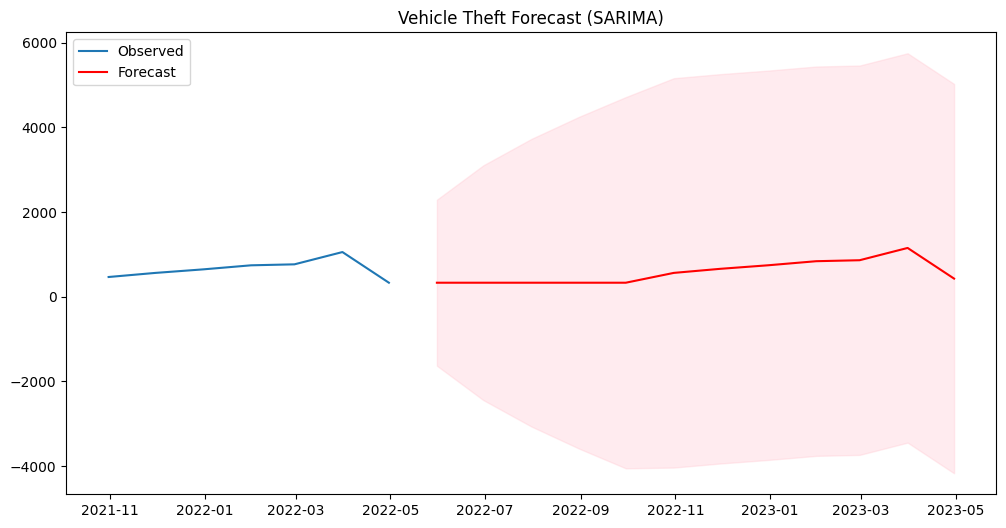

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Example: SARIMA(p,d,q)(P,D,Q,s) with yearly seasonality (s=12 for monthly data)
model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

print(results.summary())

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()


plt.figure(figsize=(12,6))
plt.plot(ts, label="Observed")
plt.plot(pred.index, pred, label="Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], 
                 color="pink", alpha=0.3)
plt.title("Vehicle Theft Forecast (SARIMA)")
plt.legend()
plt.show()


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


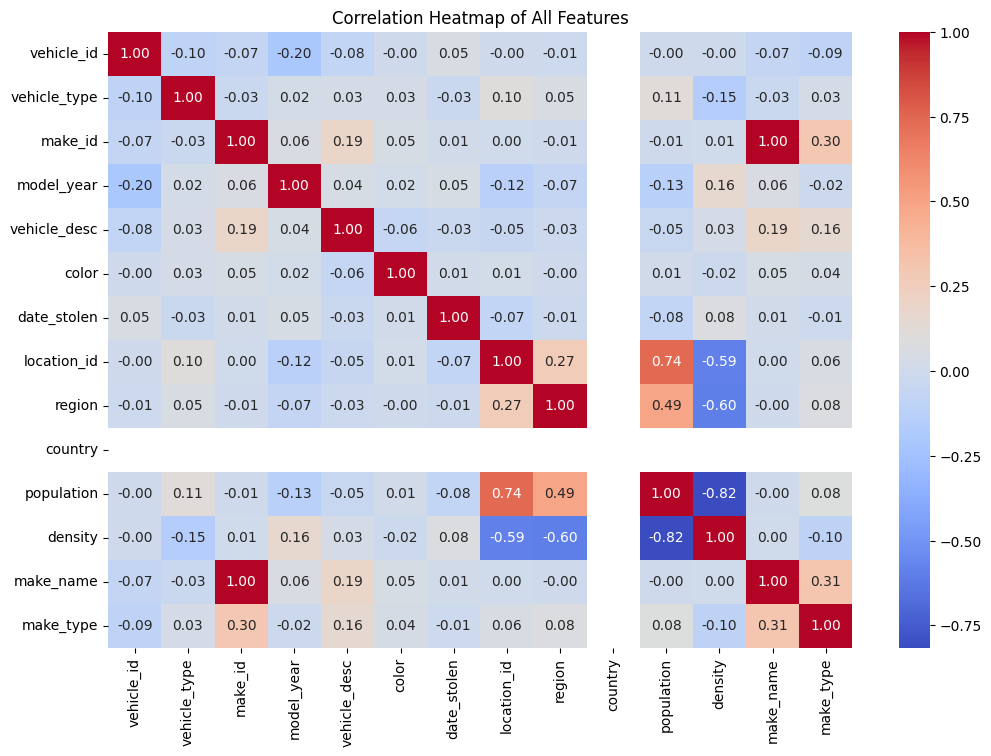

In [33]:
!pip install seaborn
import seaborn as sns
df_encoded = total_merge_data.copy()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr = df_encoded.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of All Features")
plt.show()